In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('datasets/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv/bidmc_01_Signals.csv')
print(df.columns.tolist())
print(df.head(5))
pulse_rate=125

In [ ]:
df.describe()

In [ ]:
df.iloc[:100,2:3]

In [ ]:
import matplotlib.pyplot as plt
sample_size=100 #100 to capture the whole wave from origin
plt.figure(figsize=(12,4))
plt.plot(df.iloc[:sample_size,:1], df.iloc[:sample_size,2:3])
plt.xlabel('Time (s)')
plt.ylabel('PLETH Signal')
plt.title('PPG Signal Over Time')

In [ ]:
mask=df['Time [s]']<=10
plt.figure(figsize=(12,4))
plt.plot(df['Time [s]'][mask], df[' PLETH'][mask])
plt.xlabel('Time (s)')
plt.ylabel('PPG Amplitude')
plt.title('PPG Signal Over Time')

In [ ]:
from scipy.signal import find_peaks
import numpy as np
PLETH=df[df['Time [s]']<=10][' PLETH']
PLETH

In [ ]:
threshold=np.mean(PLETH)+1.5*np.std(PLETH)
threshold

In [ ]:
peaks,peak_heights=find_peaks(PLETH,height=threshold,distance=distance)
print(f'The peaks are at position {peaks}\n')
print(f'Their corresponding heights are: {peak_heights}\n')

In [ ]:
distance=int((pulse_rate*60)/200)
distance

In [ ]:
PLETH[peaks]

In [ ]:
time=df[df['Time [s]']<=10]['Time [s]'].values
time

In [ ]:
plt.plot(time, PLETH)
plt.xlabel('Time (s)')
plt.ylabel('PLETH Signal')

In [ ]:
plt.plot(time,PLETH)
plt.plot(time[peaks],PLETH[peaks],'ro')

In [ ]:
print(pleth)

In [ ]:
print(PLETH)


In [ ]:
rr_intervals=np.diff(time[peaks])
rr_intervals

In [ ]:
Heart_Rate=int(np.average(np.astype((60/rr_intervals),int)))
Heart_Rate

In [ ]:
rms=np.sqrt((np.average(rr_intervals**2)))
rms

In [ ]:
def extract_features(rr_intervals):
    # Step 1: clean RR intervals (remove missed peaks)
    rr_intervals = rr_intervals[rr_intervals < 1.5 * np.median(rr_intervals)]
    rr_diff=np.diff(rr_intervals)

    # Step 2: mean_hr
    mean_hr = np.mean(60/rr_intervals)

    # Step 3: rmssd
    rmssd = np.sqrt(np.mean(rr_diff**2))

    # Step 4: pnn50
    # hint: count how many consecutive RR differences exceed 50ms (0.05s)
    pnn50=(np.sum(np.abs(rr_diff)>0.05)/len(rr_diff))*100
    # Step 5: sdnn (std of RR intervals)
    sdnn = np.std(rr_intervals)

    # Step 6: SD1 and SD2 (Poincare features)
    # SD1 = std of (RR[i+1] - RR[i]) / sqrt(2)
    # SD2 = std of (RR[i+1] + RR[i]) / sqrt(2)
    SD1 = np.std(rr_diff)/np.sqrt(2)
    SD2 = np.std(rr_intervals[:-1] + rr_intervals[1:]) / np.sqrt(2)

    # Step 7: Calculate HRV:
    hrv=np.std(60/rr_intervals)

    #Step 8: Shannon Entropy
    bins = min(10, len(rr_intervals) // 2)
    hist, _ = np.histogram(rr_intervals, bins=bins)
    # hist, _ = np.histogram(rr_intervals, bins=10)
    hist = hist[hist > 0]
    prob = hist / hist.sum()  # convert to probabilities (sum = 1)
    shannon_entropy=-np.sum(prob * np.log2(prob))

    # Extract HR from FFT
    mask_hr = (xf >= 0.5) & (xf <= 3.0)
    dominant_freq = xf[mask_hr][np.argmax(np.abs(yf[mask_hr]))]
    hr_from_fft = dominant_freq * 60

    return {
        'mean_hr': mean_hr,
        'hr_from_fft':hr_from_fft,
        'rmssd': rmssd,
        'pnn50': pnn50,
        'sdnn': sdnn,
        'SD1': SD1,
        'SD2': SD2,
        'shannon_entropy':shannon_entropy
    }

In [ ]:
extract_features(rr_intervals)

In [ ]:
# Poincare Plot
rr_clean = rr_intervals[rr_intervals < 1.5 * np.median(rr_intervals)]

rr1 = rr_clean[:-1]  # RR[i]
rr2 = rr_clean[1:]   # RR[i+1]

plt.figure(figsize=(6,6))
plt.scatter(rr1, rr2, alpha=0.7, color='cyan', s=50)
plt.xlabel('RR[i] (seconds)')
plt.ylabel('RR[i+1] (seconds)')
plt.title('Poincaré Plot')
plt.axline((0.6, 0.6), slope=1, color='red', linestyle='--', label='Line of Identity')
plt.legend()
plt.show()

In [ ]:
mask = df['Time [s]'] <= 60
pleth_60 = df[' PLETH'][mask].values
time_60 = df['Time [s]'][mask].values

peaks_60, _ = find_peaks(pleth_60,
                          height=np.mean(pleth_60) + 1.5*np.std(pleth_60),
                          distance=37)

rr_60 = np.diff(time_60[peaks_60])
rr_clean_60 = rr_60[rr_60 < 1.5 * np.median(rr_60)]

rr1 = rr_clean_60[:-1]
rr2 = rr_clean_60[1:]

plt.figure(figsize=(6,6))
plt.scatter(rr1, rr2, alpha=0.7, color='cyan', s=50)
plt.xlabel('RR[i] (seconds)')
plt.ylabel('RR[i+1] (seconds)')
plt.title('Poincaré Plot - 60 seconds')
plt.axline((0.6, 0.6), slope=1, color='red', linestyle='--')
plt.show()

In [ ]:
from scipy.fft import fft, fftfreq

# Use 60 seconds of clean signal
mask = df['Time [s]'] <= 60
pleth_60 = df[' PLETH'][mask].values
time_60 = df['Time [s]'][mask].values

# Fourier Transform
N = len(pleth_60)  # number of samples
T = 1/pulse_rate  # time between samples (1/sampling rate)

yf = fft(pleth_60)
xf = fftfreq(N, T)

# Only plot positive frequencies up to 10 Hz
mask_freq = (xf >= 0) & (xf <= 10)

plt.figure(figsize=(12, 4))
plt.plot(xf[mask_freq], np.abs(yf[mask_freq]))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Fourier Transform of PPG Signal')
plt.axvspan(0.15, 0.4, alpha=0.2, color='blue', label='Breathing range')
plt.axvspan(1.0, 2.0, alpha=0.2, color='green', label='Heart rate range')
plt.legend()
plt.show()

In [ ]:
# Find dominant frequency in heart rate range
mask_hr = (xf >= 0.5) & (xf <= 3.0)
dominant_freq = xf[mask_hr][np.argmax(np.abs(yf[mask_hr]))]
hr_from_fft = dominant_freq * 60
print(f"HR from FFT: {hr_from_fft:.1f} BPM")

In [273]:
import os

def process_patient(filepath,filename):
    # Step 1: load CSV
    df = pd.read_csv(filepath)

    # Step 2: extract PLETH and time
    pleth = df[' PLETH']
    time = df['Time [s]']

    # Step 3: detect peaks
    threshold = np.mean(pleth)+1.5*np.std(pleth)
    distance = int((pulse_rate*60)/200)
    peaks, _ = find_peaks(pleth, height=threshold, distance=distance)

    # Step 4: calculate RR intervals
    rr_intervals = np.diff(time.values[peaks])

    # Step 5: check minimum peaks (if less than 5 peaks, skip this patient)
    if len(peaks) < 5:
        return None

    # Step 6: extract features
    features = extract_features(rr_intervals)

    # Step 7: add patient ID from filename
    features['patient_id'] = filename.replace('_Signals.csv', '')

    return features

# Main loop
csv_folder = '/home/devanshvishwa/Documents/Github/pulse-next-band/datasets/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv/'
all_features = []

for filename in os.listdir(csv_folder):
    if filename.endswith('_Signals.csv'):
        filepath = '{}/{}'.format(csv_folder, filename)
        features = process_patient(filepath,filename)
        if features is not None:
            all_features.append(features)

# Build dataframe
df_features = pd.DataFrame(all_features)
print(df_features.shape)
print(df_features.head())

(53, 8)
     mean_hr     rmssd      pnn50      sdnn       SD1       SD2  \
0  91.236469  0.021568   1.732283  0.014550  0.015251  0.013781   
1  76.374194  0.405536  51.965066  0.318500  0.286758  0.347965   
2  76.484557  0.026332   0.702988  0.025626  0.018619  0.031121   
3  92.529240  0.028259   1.720430  0.031160  0.019981  0.038989   
4  99.242170  0.037418   8.717949  0.023131  0.026458  0.019352   

   shannon_entropy patient_id  
0         2.122932   bidmc_01  
1         1.247930   bidmc_02  
2         0.736624   bidmc_03  
3         1.121363   bidmc_04  
4         1.775792   bidmc_05  


In [274]:
print(df_features.head())
print(df_features.isnull().sum())

     mean_hr     rmssd      pnn50      sdnn       SD1       SD2  \
0  91.236469  0.021568   1.732283  0.014550  0.015251  0.013781   
1  76.374194  0.405536  51.965066  0.318500  0.286758  0.347965   
2  76.484557  0.026332   0.702988  0.025626  0.018619  0.031121   
3  92.529240  0.028259   1.720430  0.031160  0.019981  0.038989   
4  99.242170  0.037418   8.717949  0.023131  0.026458  0.019352   

   shannon_entropy patient_id  
0         2.122932   bidmc_01  
1         1.247930   bidmc_02  
2         0.736624   bidmc_03  
3         1.121363   bidmc_04  
4         1.775792   bidmc_05  
mean_hr            0
rmssd              0
pnn50              0
sdnn               0
SD1                0
SD2                0
shannon_entropy    0
patient_id         0
dtype: int64


In [278]:
df_features.isnull().sum()

mean_hr            0
rmssd              0
pnn50              0
sdnn               0
SD1                0
SD2                0
shannon_entropy    0
patient_id         0
dtype: int64

In [279]:
df_features.to_csv('datasets/bidmc_features.csv', index=False)
print("Saved!")

Saved!


Pulsewatch dataset

In [3]:
import pandas as pd
df=pd.read_csv('datasets/bidmc_features.csv')
df.head()

,mean_hr,rmssd,pnn50,sdnn,SD1,SD2,shannon_entropy,patient_id
0,91.236469,0.021568,1.732283,0.014550,0.015251,0.013781,2.122932,bidmc_01
1,76.374194,0.405536,51.965066,0.318500,0.286758,0.347965,1.247930,bidmc_02
2,76.484557,0.026332,0.702988,0.025626,0.018619,0.031121,0.736624,bidmc_03
3,92.529240,0.028259,1.720430,0.031160,0.019981,0.038989,1.121363,bidmc_04
4,99.242170,0.037418,8.717949,0.023131,0.026458,0.019352,1.775792,bidmc_05


In [8]:
import os

pulsewatch_path = '/home/devanshvishwa/Documents/Github/pulse-next-band/datasets/pulsewatch/PulsewatchRelease/Synapse/02_AF_Trial'
print(os.listdir(pulsewatch_path))

['413_final.tar', '411_final.tar', '321_final.tar', '320_final.tar', '328_final.tar']


In [9]:
import tarfile
import os

tar_folder = '/home/devanshvishwa/Documents/Github/pulse-next-band/datasets/pulsewatch/PulsewatchRelease/Synapse/02_AF_Trial/'
extract_folder = tar_folder  # extract in same folder

for filename in os.listdir(tar_folder):
    if filename.endswith('.tar'):
        tar_path = os.path.join(tar_folder, filename)
        print(f"Extracting {filename}...")
        with tarfile.open(tar_path, 'r') as tar:
            tar.extractall(extract_folder)
        print(f"Done: {filename}")

print("All extracted!")

Extracting 413_final.tar...


/tmp/ipykernel_20220/3307497961.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_folder)


Done: 413_final.tar
Extracting 411_final.tar...
Done: 411_final.tar
Extracting 321_final.tar...
Done: 321_final.tar
Extracting 320_final.tar...
Done: 320_final.tar
Extracting 328_final.tar...
Done: 328_final.tar
All extracted!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
ppg_file = '/home/devanshvishwa/Documents/Github/pulse-next-band/datasets/pulsewatch/PulsewatchRelease/Synapse/02_AF_Trial/320_final/320_2020_08_05_13_14_31_ppg_0000.txt'

df = pd.read_csv(ppg_file)
print(df.columns.tolist())
print(df.head())

['   1.59664767149400e+12   2.09713400000000e+06   0.00000000000000e+00']
  1.59664767149400e+12   2.09713400000000e+06   0.00000000000000e+00
0     1.59664767151700e+12   3.77936900000000e+06...                
1     1.59664767153600e+12   3.77936900000000e+06...                
2     1.59664767155600e+12   4.00726400000000e+06...                
3     1.59664767157600e+12   4.00726400000000e+06...                
4     1.59664767159700e+12   4.00726400000000e+06...                


In [12]:
df = pd.read_csv(ppg_file, sep=r'\s+', header=0, 
                 names=['timestamp', 'ppg_raw', 'status'])
print(df.head())
print(f"Sampling rate check - time diff: {df['timestamp'].diff().median()} ms")

      timestamp    ppg_raw  status
0  1.596648e+12  3779369.0     0.0
1  1.596648e+12  3779369.0     0.0
2  1.596648e+12  4007264.0     0.0
3  1.596648e+12  4007264.0     0.0
4  1.596648e+12  4007264.0     0.0
Sampling rate check - time diff: 20.0 ms


In [14]:
distance=int((50*60)/200)
distance

15

In [16]:
df['time_sec']=(df.timestamp-df.timestamp.iloc[0])/1000
df

,timestamp,ppg_raw,status,time_sec
0,1.596648e+12,3779369.0,0.0,0.000
1,1.596648e+12,3779369.0,0.0,0.019
2,1.596648e+12,4007264.0,0.0,0.039
3,1.596648e+12,4007264.0,0.0,0.059
4,1.596648e+12,4007264.0,0.0,0.080
...,...,...,...,...
1494,1.596648e+12,2724204.0,74.0,29.898
1495,1.596648e+12,2724204.0,74.0,29.920
1496,1.596648e+12,2724204.0,74.0,29.939
1497,1.596648e+12,2725309.0,74.0,29.959


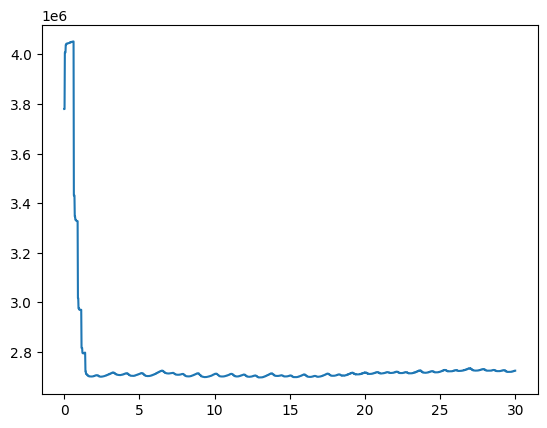

In [36]:
sample_df=df[(df.time_sec<=30)]
plt.plot(sample_df.time_sec,sample_df.ppg_raw)
plt.show()

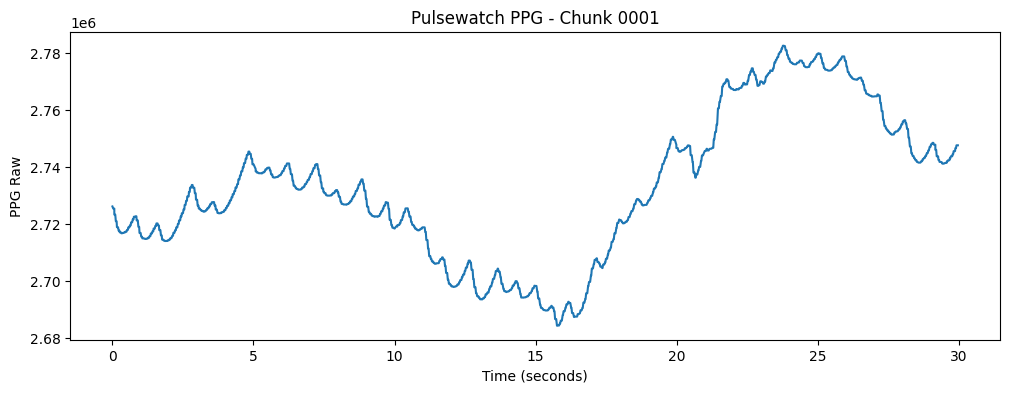

In [37]:
ppg_file = '/home/devanshvishwa/Documents/Github/pulse-next-band/datasets/pulsewatch/PulsewatchRelease/Synapse/02_AF_Trial/320_final/320_2020_08_05_13_14_31_ppg_0001.txt'

df = pd.read_csv(ppg_file, sep=r'\s+', header=0,
                 names=['timestamp', 'ppg_raw', 'status'])

df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000

plt.figure(figsize=(12,4))
plt.plot(df['time_sec'], df['ppg_raw'])
plt.title('Pulsewatch PPG - Chunk 0001')
plt.xlabel('Time (seconds)')
plt.ylabel('PPG Raw')
plt.show()

In [38]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=3.5, fs=50, order=4):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

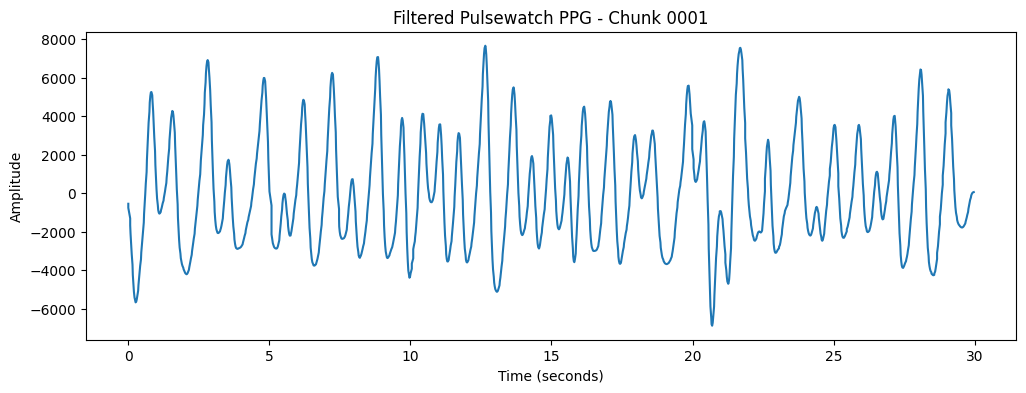

In [39]:
filtered_ppg = bandpass_filter(df['ppg_raw'].values)

plt.figure(figsize=(12,4))
plt.plot(df['time_sec'], filtered_ppg)
plt.title('Filtered Pulsewatch PPG - Chunk 0001')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

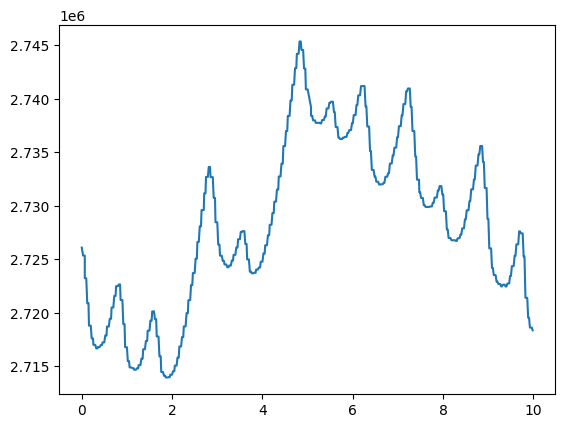

In [47]:
plt.plot(df[df.time_sec<=10].time_sec,df[df.time_sec<=10].ppg_raw)